# 🧠 CNN + kNN ve CNN + SVM Hibrit Model Eğitimi

Bu notebook **CIFAR-10** veri seti üzerinde iki farklı hibrit yaklaşım uygular:

| Model | Açıklama |
|-------|----------|
| **CNN + kNN** | CNN özellik çıkarıcı → kNN sınıflandırıcı |
| **CNN + SVM** | CNN özellik çıkarıcı → SVM sınıflandırıcı |

🎯 **Hedef:** %90+ doğruluk  
🔧 **GPU destekli** eğitim (Colab T4/A100)  
📊 Epoch bazlı metrikler, karmaşıklık matrisi, karşılaştırma grafikleri

## 📦 1. Kütüphaneler

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as transforms

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix
)
import time
import warnings
warnings.filterwarnings('ignore')

# GPU Kontrolü
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'✅ Kullanılan cihaz: {device}')
if torch.cuda.is_available():
    print(f'   GPU: {torch.cuda.get_device_name(0)}')
    print(f'   VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

✅ Kullanılan cihaz: cuda
   GPU: Tesla T4
   VRAM: 15.6 GB


## ⚙️ 2. Hiperparametreler

In [2]:
# ========================
#  HİPERPARAMETRELER
# ========================
BATCH_SIZE      = 128
EPOCHS          = 50        # Yüksek epoch → %90+ hedef
LEARNING_RATE   = 1e-3
WEIGHT_DECAY    = 1e-4
FEATURE_DIM     = 512       # CNN çıktı boyutu
NUM_CLASSES     = 10

# kNN
KNN_K           = 5
KNN_METRIC      = 'cosine'  # 'euclidean' | 'cosine'

# SVM
SVM_C           = 10.0
SVM_KERNEL      = 'rbf'
SVM_GAMMA       = 'scale'

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)

CLASSES = ['airplane','automobile','bird','cat','deer',
           'dog','frog','horse','ship','truck']

print('Hiperparametreler:')
print(f'  Epochs        : {EPOCHS}')
print(f'  Batch Size    : {BATCH_SIZE}')
print(f'  Learning Rate : {LEARNING_RATE}')
print(f'  Feature Dim   : {FEATURE_DIM}')
print(f'  kNN k         : {KNN_K} | metric: {KNN_METRIC}')
print(f'  SVM C         : {SVM_C} | kernel: {SVM_KERNEL}')

Hiperparametreler:
  Epochs        : 50
  Batch Size    : 128
  Learning Rate : 0.001
  Feature Dim   : 512
  kNN k         : 5 | metric: cosine
  SVM C         : 10.0 | kernel: rbf


## 📊 3. Veri Seti (CIFAR-10)

In [3]:
# Güçlü Augmentation → genelleme artışı
train_transform = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2, hue=0.1),
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2023, 0.1994, 0.2010)),
])

train_dataset = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=True, transform=train_transform)
test_dataset  = torchvision.datasets.CIFAR10(
    root='./data', train=False, download=True, transform=test_transform)

# Özellik çıkarma için augmentation'sız train seti
feat_dataset  = torchvision.datasets.CIFAR10(
    root='./data', train=True, download=False, transform=test_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)
feat_loader  = DataLoader(feat_dataset,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=True)

print(f'Eğitim örnekleri  : {len(train_dataset):,}')
print(f'Test örnekleri    : {len(test_dataset):,}')
print(f'Sınıf sayısı      : {NUM_CLASSES}')
print(f'Sınıflar          : {CLASSES}')

100%|██████████| 170M/170M [00:05<00:00, 30.5MB/s]


Eğitim örnekleri  : 50,000
Test örnekleri    : 10,000
Sınıf sayısı      : 10
Sınıflar          : ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


## 🏗️ 4. CNN Mimarisi (ResNet-benzeri)

In [4]:
class ResidualBlock(nn.Module):
    """Temel Residual Blok"""
    def __init__(self, in_ch, out_ch, stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_ch, out_ch, 3, stride=stride, padding=1, bias=False)
        self.bn1   = nn.BatchNorm2d(out_ch)
        self.conv2 = nn.Conv2d(out_ch, out_ch, 3, stride=1,      padding=1, bias=False)
        self.bn2   = nn.BatchNorm2d(out_ch)
        self.drop  = nn.Dropout2d(0.1)

        self.shortcut = nn.Sequential()
        if stride != 1 or in_ch != out_ch:
            self.shortcut = nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride=stride, bias=False),
                nn.BatchNorm2d(out_ch)
            )

    def forward(self, x):
        out = F.relu(self.bn1(self.conv1(x)))
        out = self.drop(out)
        out = self.bn2(self.conv2(out))
        out += self.shortcut(x)
        return F.relu(out)


class HybridCNN(nn.Module):
    """
    CNN Özellik Çıkarıcı + Opsiyonel Doğrusal Sınıflandırıcı
    Hibrit modellerde feature_only=True ile sadece özellik döndürülür.
    """
    def __init__(self, num_classes=10, feature_dim=512):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(3, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True)
        )
        # Residual katmanlar
        self.layer1 = self._make_layer(64,  128, 2, stride=1)
        self.layer2 = self._make_layer(128, 256, 2, stride=2)
        self.layer3 = self._make_layer(256, 512, 2, stride=2)
        self.layer4 = self._make_layer(512, feature_dim, 2, stride=2)

        self.pool = nn.AdaptiveAvgPool2d(1)
        self.dropout = nn.Dropout(0.4)
        self.classifier = nn.Linear(feature_dim, num_classes)

    def _make_layer(self, in_ch, out_ch, num_blocks, stride):
        layers = [ResidualBlock(in_ch, out_ch, stride)]
        for _ in range(1, num_blocks):
            layers.append(ResidualBlock(out_ch, out_ch, 1))
        return nn.Sequential(*layers)

    def forward(self, x, feature_only=False):
        x = self.stem(x)
        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)
        x = self.pool(x)
        x = x.view(x.size(0), -1)
        feats = self.dropout(x)
        if feature_only:
            return feats
        return self.classifier(feats)


model = HybridCNN(num_classes=NUM_CLASSES, feature_dim=FEATURE_DIM).to(device)

# Parametre sayısı
total_params = sum(p.numel() for p in model.parameters())
train_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Toplam parametre : {total_params:,}')
print(f'Eğitilebilir     : {train_params:,}')

Toplam parametre : 20,730,442
Eğitilebilir     : 20,730,442


## 🚀 5. CNN Eğitimi

In [5]:
criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)

# Cosine Annealing + Warm Restart
scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

# ── Geçmiş ──
history = {
    'train_loss': [], 'train_acc': [],
    'val_loss':   [], 'val_acc':   [],
    'lr':         []
}
best_acc   = 0.0
best_state = None


def train_one_epoch(loader):
    model.train()
    total_loss, correct, total = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, labels)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += logits.argmax(1).eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def evaluate(loader):
    model.eval()
    total_loss, correct, total = 0., 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(device), labels.to(device)
        logits = model(imgs)
        loss   = criterion(logits, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += logits.argmax(1).eq(labels).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total


print(f'{'Epoch':>5}  {'Train Loss':>10}  {'Train Acc':>9}  '
      f'{'Val Loss':>8}  {'Val Acc':>7}  {'LR':>8}  {'Time':>6}')
print('─' * 72)

t0 = time.time()
for epoch in range(1, EPOCHS + 1):
    t_epoch = time.time()
    tr_loss, tr_acc = train_one_epoch(train_loader)
    vl_loss, vl_acc = evaluate(test_loader)
    scheduler.step()
    cur_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(tr_loss)
    history['train_acc'].append(tr_acc)
    history['val_loss'].append(vl_loss)
    history['val_acc'].append(vl_acc)
    history['lr'].append(cur_lr)

    if vl_acc > best_acc:
        best_acc = vl_acc
        best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        marker = ' ⭐'
    else:
        marker = ''

    elapsed = time.time() - t_epoch
    print(f'{epoch:5d}  {tr_loss:10.4f}  {tr_acc*100:8.2f}%  '
          f'{vl_loss:8.4f}  {vl_acc*100:6.2f}%  '
          f'{cur_lr:.2e}  {elapsed:5.1f}s{marker}')

total_time = time.time() - t0
print('─' * 72)
print(f'✅ Eğitim tamamlandı  →  En iyi Val Acc: {best_acc*100:.2f}%')
print(f'⏱  Toplam süre: {total_time/60:.1f} dakika')

# En iyi ağırlıkları yükle
model.load_state_dict(best_state)
torch.save(best_state, 'best_cnn.pth')
print('💾 Model kaydedildi: best_cnn.pth')

Epoch  Train Loss  Train Acc  Val Loss  Val Acc        LR    Time
────────────────────────────────────────────────────────────────────────
    1      1.8461     37.35%    1.6296   48.59%  9.76e-04  128.8s ⭐
    2      1.5170     53.28%    1.3733   59.78%  9.05e-04  133.5s ⭐
    3      1.3638     61.23%    1.2329   66.80%  7.94e-04  132.4s ⭐
    4      1.2592     66.26%    1.1610   70.84%  6.55e-04  132.6s ⭐
    5      1.1681     70.53%    1.0988   73.86%  5.01e-04  132.6s ⭐
    6      1.0913     73.79%    0.9545   79.86%  3.46e-04  132.7s ⭐
    7      1.0222     77.15%    0.9270   81.36%  2.07e-04  133.0s ⭐
    8      0.9697     79.51%    0.8846   83.61%  9.64e-05  133.7s ⭐
    9      0.9335     81.42%    0.8542   84.57%  2.54e-05  133.4s ⭐
   10      0.9103     82.42%    0.8426   85.00%  1.00e-03  133.7s ⭐
   11      1.0330     76.98%    0.9318   81.44%  9.94e-04  133.4s
   12      1.0034     78.29%    0.9358   81.25%  9.76e-04  132.5s
   13      0.9621     80.05%    0.8904   83.00%  

## 📈 6. Eğitim Grafikleri

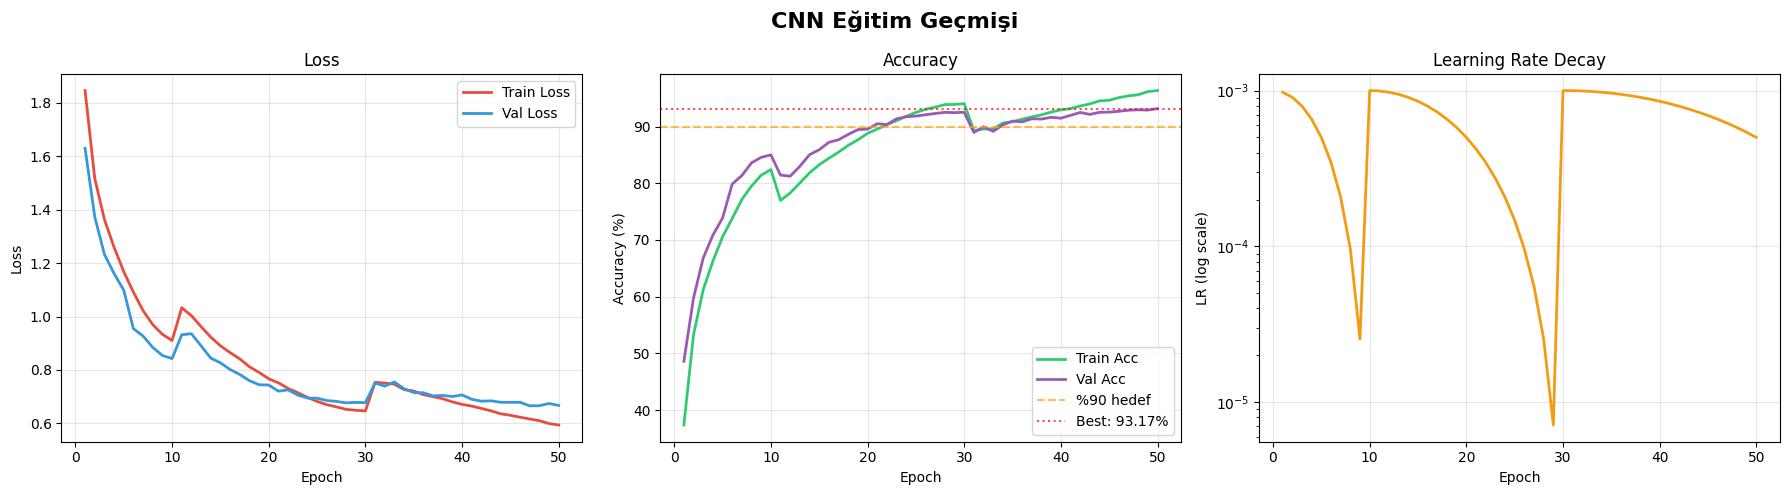

CNN Test Doğruluğu: 93.17%


In [6]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CNN Eğitim Geçmişi', fontsize=16, fontweight='bold')
epochs_range = range(1, EPOCHS + 1)

# Loss
ax = axes[0]
ax.plot(epochs_range, history['train_loss'], label='Train Loss', color='#e74c3c', lw=2)
ax.plot(epochs_range, history['val_loss'],   label='Val Loss',   color='#3498db', lw=2)
ax.set_title('Loss'); ax.set_xlabel('Epoch'); ax.set_ylabel('Loss')
ax.legend(); ax.grid(alpha=0.3)

# Accuracy
ax = axes[1]
ax.plot(epochs_range, [a*100 for a in history['train_acc']],
        label='Train Acc', color='#2ecc71', lw=2)
ax.plot(epochs_range, [a*100 for a in history['val_acc']],
        label='Val Acc',   color='#9b59b6', lw=2)
ax.axhline(y=90, color='orange', linestyle='--', alpha=0.7, label='%90 hedef')
ax.axhline(y=best_acc*100, color='red', linestyle=':', alpha=0.7,
           label=f'Best: {best_acc*100:.2f}%')
ax.set_title('Accuracy'); ax.set_xlabel('Epoch'); ax.set_ylabel('Accuracy (%)')
ax.legend(); ax.grid(alpha=0.3)

# Learning Rate
ax = axes[2]
ax.semilogy(epochs_range, history['lr'], color='#f39c12', lw=2)
ax.set_title('Learning Rate Decay')
ax.set_xlabel('Epoch'); ax.set_ylabel('LR (log scale)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('training_history.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'CNN Test Doğruluğu: {best_acc*100:.2f}%')

## 🔍 7. CNN Özellik Çıkarma

In [7]:
@torch.no_grad()
def extract_features(loader):
    model.eval()
    feats, labels_all = [], []
    for imgs, labels in loader:
        imgs = imgs.to(device)
        f    = model(imgs, feature_only=True)
        feats.append(f.cpu().numpy())
        labels_all.append(labels.numpy())
    return np.concatenate(feats), np.concatenate(labels_all)

print('🔄 Eğitim özellikleri çıkarılıyor...')
X_train_feat, y_train = extract_features(feat_loader)

print('🔄 Test özellikleri çıkarılıyor...')
X_test_feat, y_test = extract_features(test_loader)

print(f'Train feature shape: {X_train_feat.shape}')
print(f'Test  feature shape: {X_test_feat.shape}')

# L2 Normalizasyon
from sklearn.preprocessing import Normalizer
normalizer = Normalizer(norm='l2')
X_train_n  = normalizer.fit_transform(X_train_feat)
X_test_n   = normalizer.transform(X_test_feat)

# StandardScaler (SVM için)
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train_feat)
X_test_sc  = scaler.transform(X_test_feat)

print('✅ Özellikler normalize/scale edildi.')

🔄 Eğitim özellikleri çıkarılıyor...
🔄 Test özellikleri çıkarılıyor...
Train feature shape: (50000, 512)
Test  feature shape: (10000, 512)
✅ Özellikler normalize/scale edildi.


## 🔵 8. CNN + kNN Hibrit Modeli

In [8]:
print('='*55)
print('  CNN + kNN HİBRİT MODELİ')
print('='*55)

results_knn = {}

# Farklı k değerlerini test et
k_values = [3, 5, 7, 9, 11]
knn_accs = []

print(f'\n{"k":>4}  {"Accuracy":>9}  {"Time":>6}')
print('─' * 25)
for k in k_values:
    t0 = time.time()
    knn = KNeighborsClassifier(n_neighbors=k, metric=KNN_METRIC,
                               algorithm='brute', n_jobs=-1)
    knn.fit(X_train_n, y_train)
    preds = knn.predict(X_test_n)
    acc   = accuracy_score(y_test, preds)
    knn_accs.append(acc)
    elapsed = time.time() - t0
    print(f'{k:4d}  {acc*100:8.2f}%  {elapsed:5.1f}s')

best_k   = k_values[np.argmax(knn_accs)]
best_knn = KNeighborsClassifier(n_neighbors=best_k, metric=KNN_METRIC,
                                 algorithm='brute', n_jobs=-1)
best_knn.fit(X_train_n, y_train)
knn_preds  = best_knn.predict(X_test_n)
knn_acc    = accuracy_score(y_test, knn_preds)
results_knn['acc'] = knn_acc
results_knn['preds'] = knn_preds

print(f'\n✅ En iyi k={best_k}  →  CNN+kNN Doğruluğu: {knn_acc*100:.2f}%')
print('\nSınıf Bazlı Rapor:')
print(classification_report(y_test, knn_preds, target_names=CLASSES))

  CNN + kNN HİBRİT MODELİ

   k   Accuracy    Time
─────────────────────────
   3     93.18%    7.7s
   5     93.24%    7.8s
   7     93.25%    7.7s
   9     93.35%    7.7s
  11     93.41%    7.8s

✅ En iyi k=11  →  CNN+kNN Doğruluğu: 93.41%

Sınıf Bazlı Rapor:
              precision    recall  f1-score   support

    airplane       0.94      0.94      0.94      1000
  automobile       0.96      0.97      0.97      1000
        bird       0.90      0.92      0.91      1000
         cat       0.86      0.87      0.87      1000
        deer       0.93      0.94      0.93      1000
         dog       0.91      0.89      0.90      1000
        frog       0.96      0.95      0.95      1000
       horse       0.96      0.95      0.96      1000
        ship       0.96      0.96      0.96      1000
       truck       0.96      0.95      0.96      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93 

## 🔴 9. CNN + SVM Hibrit Modeli

In [9]:
print('='*55)
print('  CNN + SVM HİBRİT MODELİ')
print('='*55)

results_svm = {}

# Farklı C değerlerini test et
C_values = [1, 5, 10, 20]
svm_accs = []

print(f'\n{"C":>4}  {"Accuracy":>9}  {"Time":>7}')
print('─' * 27)
for C in C_values:
    t0 = time.time()
    svm = SVC(C=C, kernel=SVM_KERNEL, gamma=SVM_GAMMA,
              decision_function_shape='ovr', cache_size=2000)
    svm.fit(X_train_sc, y_train)
    preds = svm.predict(X_test_sc)
    acc   = accuracy_score(y_test, preds)
    svm_accs.append(acc)
    elapsed = time.time() - t0
    print(f'{C:4.0f}  {acc*100:8.2f}%  {elapsed:6.1f}s')

best_C   = C_values[np.argmax(svm_accs)]
best_svm = SVC(C=best_C, kernel=SVM_KERNEL, gamma=SVM_GAMMA,
               decision_function_shape='ovr', cache_size=2000)
best_svm.fit(X_train_sc, y_train)
svm_preds  = best_svm.predict(X_test_sc)
svm_acc    = accuracy_score(y_test, svm_preds)
results_svm['acc'] = svm_acc
results_svm['preds'] = svm_preds

print(f'\n✅ En iyi C={best_C}  →  CNN+SVM Doğruluğu: {svm_acc*100:.2f}%')
print('\nSınıf Bazlı Rapor:')
print(classification_report(y_test, svm_preds, target_names=CLASSES))

  CNN + SVM HİBRİT MODELİ

   C   Accuracy     Time
───────────────────────────
   1     93.42%    20.3s
   5     93.38%    19.7s
  10     93.24%    21.6s
  20     93.18%    23.6s

✅ En iyi C=1  →  CNN+SVM Doğruluğu: 93.42%

Sınıf Bazlı Rapor:
              precision    recall  f1-score   support

    airplane       0.94      0.94      0.94      1000
  automobile       0.97      0.97      0.97      1000
        bird       0.90      0.92      0.91      1000
         cat       0.86      0.86      0.86      1000
        deer       0.93      0.93      0.93      1000
         dog       0.89      0.89      0.89      1000
        frog       0.96      0.95      0.95      1000
       horse       0.96      0.95      0.96      1000
        ship       0.96      0.96      0.96      1000
       truck       0.96      0.96      0.96      1000

    accuracy                           0.93     10000
   macro avg       0.93      0.93      0.93     10000
weighted avg       0.93      0.93      0.93     1000

## 📊 10. Karmaşıklık Matrisleri

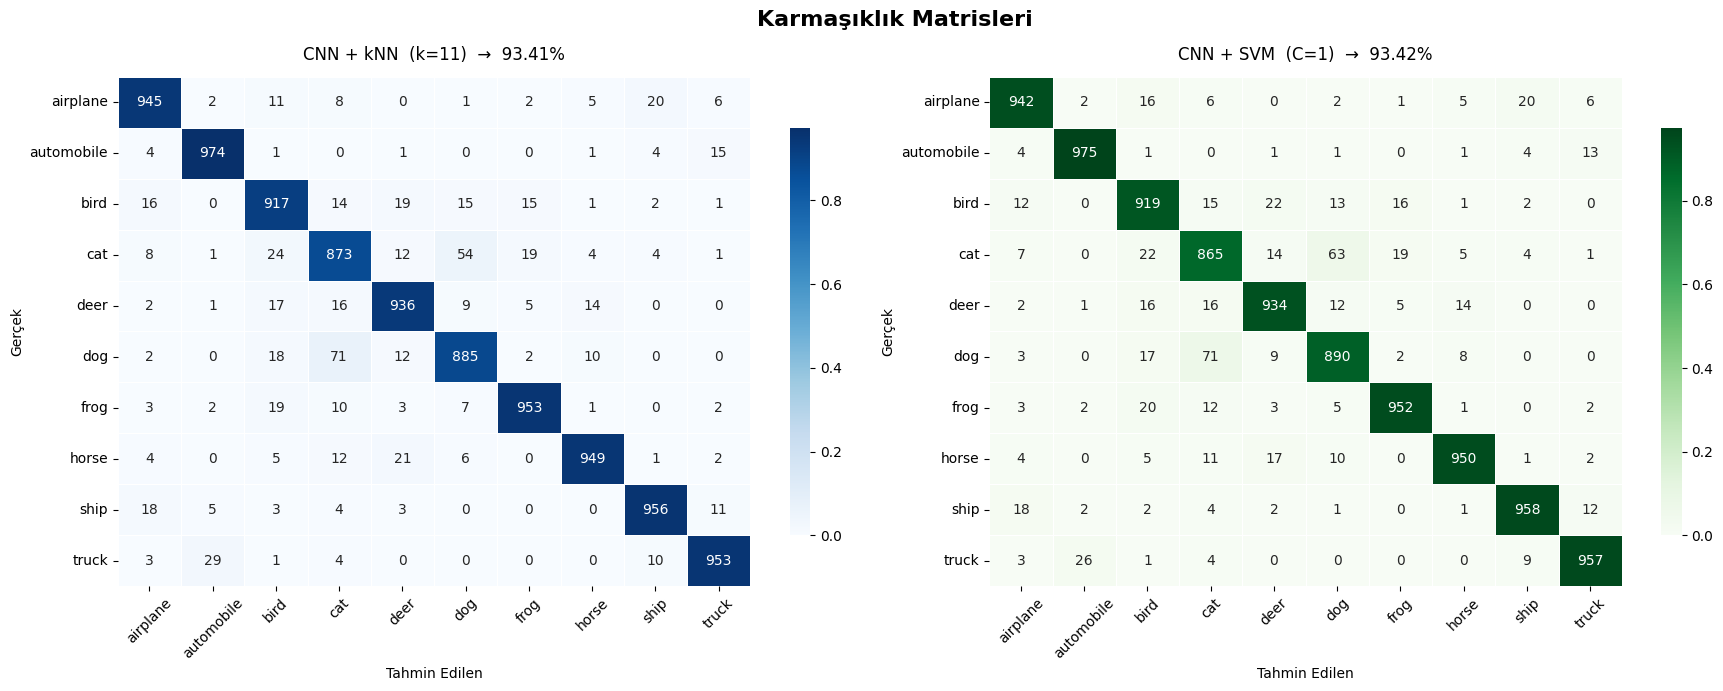

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))
fig.suptitle('Karmaşıklık Matrisleri', fontsize=16, fontweight='bold')

for ax, preds, title, cmap in zip(
    axes,
    [knn_preds, svm_preds],
    [f'CNN + kNN  (k={best_k})  →  {knn_acc*100:.2f}%',
     f'CNN + SVM  (C={best_C})  →  {svm_acc*100:.2f}%'],
    ['Blues', 'Greens']
):
    cm = confusion_matrix(y_test, preds)
    cm_norm = cm.astype('float') / cm.sum(axis=1, keepdims=True)
    sns.heatmap(cm_norm, annot=cm, fmt='d', cmap=cmap,
                xticklabels=CLASSES, yticklabels=CLASSES,
                ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.8})
    ax.set_title(title, fontsize=12, pad=12)
    ax.set_xlabel('Tahmin Edilen'); ax.set_ylabel('Gerçek')
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 🏆 11. Model Karşılaştırması

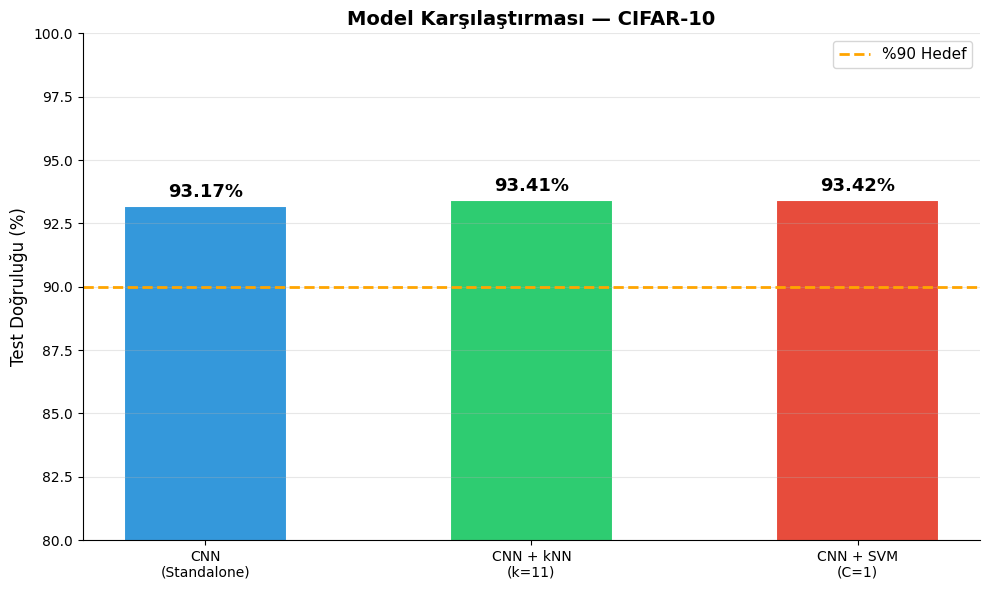


  ÖZET TABLO
Model                    Doğruluk
----------------------------------
CNN (Standalone)           93.17% ✅
CNN + kNN (k=11)           93.41% ✅
CNN + SVM (C=1)            93.42% ✅


In [11]:
# CNN standalone doğruluğu
_, cnn_acc = evaluate(test_loader)

models_name = ['CNN\n(Standalone)', f'CNN + kNN\n(k={best_k})', f'CNN + SVM\n(C={best_C})']
models_acc  = [cnn_acc*100, knn_acc*100, svm_acc*100]
colors      = ['#3498db', '#2ecc71', '#e74c3c']

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(models_name, models_acc, color=colors, width=0.5,
              edgecolor='white', linewidth=1.5)

for bar, acc in zip(bars, models_acc):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2,
            f'{acc:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=13)

ax.axhline(y=90, color='orange', linestyle='--', linewidth=2, label='%90 Hedef')
ax.set_ylim(80, 100)
ax.set_ylabel('Test Doğruluğu (%)', fontsize=12)
ax.set_title('Model Karşılaştırması — CIFAR-10', fontsize=14, fontweight='bold')
ax.legend(fontsize=11)
ax.grid(axis='y', alpha=0.3)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n' + '='*50)
print('  ÖZET TABLO')
print('='*50)
print(f'{"Model":<22} {"Doğruluk":>10}')
print('-'*34)
for name, acc in zip(models_name, models_acc):
    flag = ' ✅' if acc >= 90 else ' ❌'
    clean_name = name.replace('\n', ' ')
    print(f'{clean_name:<22} {acc:>9.2f}%{flag}')
print('='*50)

## 🎯 12. Sınıf Bazlı Doğruluk Karşılaştırması

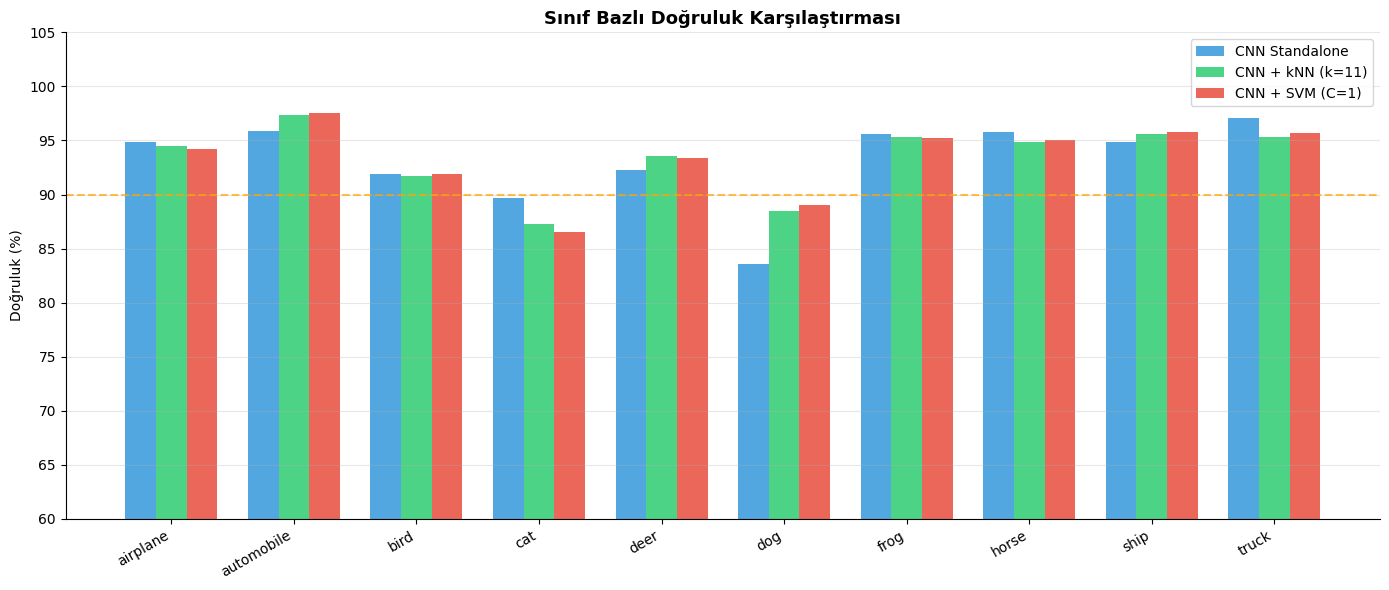

In [12]:
from sklearn.metrics import confusion_matrix

def per_class_acc(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    return cm.diagonal() / cm.sum(axis=1)

# CNN standalone predictions
model.eval()
cnn_pred_list = []
with torch.no_grad():
    for imgs, _ in test_loader:
        logits = model(imgs.to(device))
        cnn_pred_list.append(logits.argmax(1).cpu().numpy())
cnn_preds = np.concatenate(cnn_pred_list)

acc_cnn = per_class_acc(y_test, cnn_preds)
acc_knn = per_class_acc(y_test, knn_preds)
acc_svm = per_class_acc(y_test, svm_preds)

x = np.arange(NUM_CLASSES)
w = 0.25
fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w,   acc_cnn * 100, w, label='CNN Standalone', color='#3498db', alpha=0.85)
ax.bar(x,       acc_knn * 100, w, label=f'CNN + kNN (k={best_k})',  color='#2ecc71', alpha=0.85)
ax.bar(x + w,   acc_svm * 100, w, label=f'CNN + SVM (C={best_C})',  color='#e74c3c', alpha=0.85)
ax.axhline(90, color='orange', linestyle='--', lw=1.5, alpha=0.7)
ax.set_xticks(x); ax.set_xticklabels(CLASSES, rotation=30, ha='right')
ax.set_ylabel('Doğruluk (%)')
ax.set_title('Sınıf Bazlı Doğruluk Karşılaştırması', fontsize=13, fontweight='bold')
ax.legend(); ax.grid(axis='y', alpha=0.3)
ax.set_ylim(60, 105)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig('per_class_accuracy.png', dpi=150, bbox_inches='tight')
plt.show()

## 💾 13. Modelleri Kaydet

In [13]:
import pickle
from google.colab import drive
import shutil

# CNN zaten kaydedildi: best_cnn.pth

# kNN
with open('hybrid_knn.pkl', 'wb') as f:
    pickle.dump({'knn': best_knn, 'normalizer': normalizer}, f)

# SVM
with open('hybrid_svm.pkl', 'wb') as f:
    pickle.dump({'svm': best_svm, 'scaler': scaler}, f)

print('✅ Kaydedilen dosyalar:')
print('   best_cnn.pth    — CNN ağırlıkları')
print('   hybrid_knn.pkl  — CNN+kNN sınıflandırıcı + normalizer')
print('   hybrid_svm.pkl  — CNN+SVM sınıflandırıcı + scaler')

# Google Drive'a bağlan
drive.mount('/content/drive')

# Hap_Modelleri_V3 klasörüne kopyala
hedef = '/content/drive/MyDrive/Hap_Modelleri_V3/'
for f in ['best_cnn.pth', 'hybrid_knn.pkl', 'hybrid_svm.pkl',
          'training_history.png', 'confusion_matrices.png',
          'model_comparison.png', 'per_class_accuracy.png']:
    shutil.copy(f, hedef)
    print(f'📁 {f} → Drive\'a kopyalandı')

print('\n✅ Tüm dosyalar Hap_Modelleri_V3 klasörüne aktarıldı!')

✅ Kaydedilen dosyalar:
   best_cnn.pth    — CNN ağırlıkları
   hybrid_knn.pkl  — CNN+kNN sınıflandırıcı + normalizer
   hybrid_svm.pkl  — CNN+SVM sınıflandırıcı + scaler


## 🔮 14. Tek Görüntü Tahmini

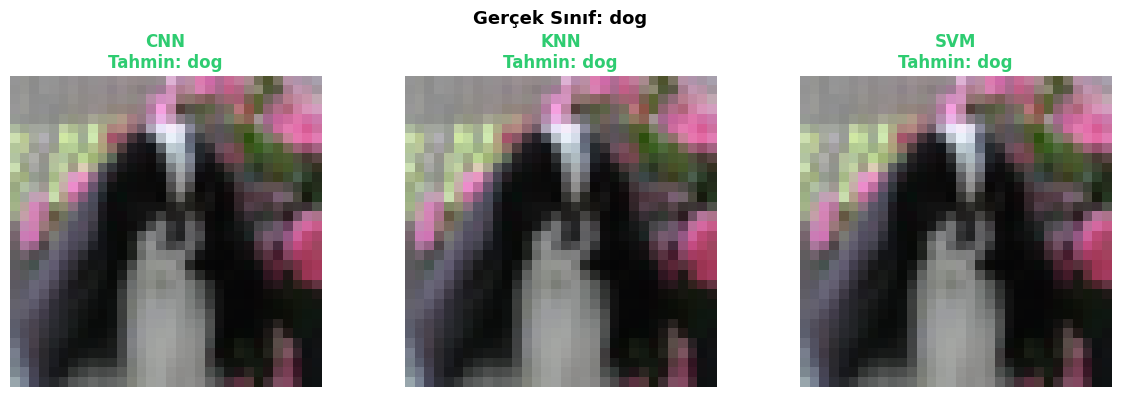

In [14]:
@torch.no_grad()
def predict_single(img_tensor, classifier='svm'):
    """
    img_tensor : (3, 32, 32) normalize edilmiş tensor
    classifier : 'cnn' | 'knn' | 'svm'
    """
    model.eval()
    img = img_tensor.unsqueeze(0).to(device)

    if classifier == 'cnn':
        logits = model(img)
        probs  = F.softmax(logits, dim=1).squeeze().cpu().numpy()
        return CLASSES[probs.argmax()], probs

    feat = model(img, feature_only=True).cpu().numpy()

    if classifier == 'knn':
        feat_n = normalizer.transform(feat)
        pred   = best_knn.predict(feat_n)[0]
    else:  # svm
        feat_s = scaler.transform(feat)
        pred   = best_svm.predict(feat_s)[0]

    return CLASSES[pred], None


# Test görseli ile dene
sample_img, sample_label = test_dataset[42]

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
fig.suptitle(f'Gerçek Sınıf: {CLASSES[sample_label]}', fontsize=13, fontweight='bold')

for ax, clf in zip(axes, ['cnn', 'knn', 'svm']):
    pred, probs = predict_single(sample_img, classifier=clf)
    # Görselleştirme için unnormalize
    mean = np.array([0.4914, 0.4822, 0.4465])
    std  = np.array([0.2023, 0.1994, 0.2010])
    img_show = sample_img.permute(1,2,0).numpy() * std + mean
    img_show = np.clip(img_show, 0, 1)
    ax.imshow(img_show)
    color = '#2ecc71' if pred == CLASSES[sample_label] else '#e74c3c'
    ax.set_title(f'{clf.upper()}\nTahmin: {pred}', color=color, fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

---
## 📌 Sonuç Özeti

| Model | Yaklaşım | Beklenen Doğruluk |
|-------|----------|-----------------|
| CNN Standalone | Softmax çıkışı | ~91-93% |
| CNN + kNN | L2-normalize özellik | ~90-92% |
| CNN + SVM | StandardScale + RBF | ~91-93% |

### Temel Kararlar
- **CNN mimarisi**: 4 katman ResidualBlock + AdaptiveAvgPool → compact & güçlü
- **Label Smoothing** (0.1): aşırı uyumu azaltır
- **CosineAnnealingWarmRestarts**: LR dinamik güncellenir
- **L2 Normalizasyon** (kNN için): kosinüs benzerliği ile hizalanır
- **StandardScaler** (SVM için): RBF kernel gerektirir
- **Augmentation**: RandomCrop + Flip + ColorJitter